In [ ]:
#Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('all libraries loaded')

TensorFlow version: 2.20.0
GPU available: []
all libraries loaded


In [ ]:
# Load datasets
NAZARIO_PATH = '/content/drive/MyDrive/CS271/Nazario.csv'
SPAM_PATH    = '/content/drive/MyDrive/CS271/spam_ham_dataset.csv'

nazario = pd.read_csv(NAZARIO_PATH)
spam    = pd.read_csv(SPAM_PATH)

print('Nazario columns:', nazario.columns.tolist())
print('Spam columns:   ', spam.columns.tolist())

Nazario columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Spam columns:    ['Unnamed: 0', 'label', 'text', 'label_num']


In [ ]:
# Merge  datasets
nazario_clean = nazario[['body', 'label']].copy()
nazario_clean.columns = ['text', 'label']

spam_clean = spam[['text', 'label_num']].copy()
spam_clean.columns = ['text', 'label']

df = pd.concat([nazario_clean, spam_clean], ignore_index=True)
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

print(f'Total samples : {len(df)}')
print(df['label'].value_counts())
print('0 = Legit  |  1 = Phishing/Spam')

Total samples : 6736
label
0    3672
1    3064
Name: count, dtype: int64
0 = Legit  |  1 = Phishing/Spam


In [ ]:
# Text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
print('data cleaned')
print('Sample:', df['text_clean'].iloc[0][:200])

data cleaned
Sample: this text is part of the internal format of your mail folder and is not a real message it is created automatically by the mail system software if deleted important folder data will be lost and it will


In [ ]:
# Train/test split
X_text = df['text_clean'].values
y      = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train_text)} samples')
print(f'Test : {len(X_test_text)} samples')

Train: 5388 samples
Test : 1348 samples


In [ ]:
#Character substitution (adversarial manipulation)

CHAR_MAP = {'a':'@', 'o':'0', 'i':'1', 'e':'3', 's':'$', 'l':'1', 'g':'9', 't':'7'}

def substitute_chars(text):
    return ''.join(CHAR_MAP.get(c, c) for c in str(text))

X_test_manip_text = np.array([substitute_chars(t) for t in X_test_text])

print('Original   :', X_test_text[0][:80])
print('Manipulated:', X_test_manip_text[0][:80])

Original   : subject new turn ons tom production commenced to flow as stated below please cre
Manipulated: $ubj3c7 n3w 7urn 0n$ 70m pr0duc710n c0mm3nc3d 70 f10w @$ $7@73d b310w p13@$3 cr3


In [ ]:
# Robust training data + TF-IDF vectorizer

# Build robust training set (clean + manipulated)
X_train_manip       = [substitute_chars(t) for t in X_train_text]
X_train_robust_text = list(X_train_text) + X_train_manip
y_train_robust      = np.concatenate([y_train, y_train])

print(f'Robust training size: {len(X_train_robust_text)} samples')

# TF-IDF fitted on robust data
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf       = tfidf.fit_transform(X_train_robust_text)
X_test_tfidf        = tfidf.transform(X_test_text)
X_test_manip_tfidf  = tfidf.transform(X_test_manip_text)

print('TF-IDF shape:', X_train_tfidf.shape)

Robust training size: 10776 samples
TF-IDF shape: (10776, 5000)


In [ ]:
# Evaluation helpers

results_clean = {}
results_manip = {}
results_adv   = {}
roc_data      = {}

def evaluate(name, y_true, y_pred, y_prob, split='clean'):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    fnr = 1 - tpr
    eer = float(fpr[np.nanargmin(np.abs(fnr - fpr))])

    metrics = dict(Accuracy=acc, F1=f1, Precision=prec, Recall=rec, AUC=roc_auc, EER=eer)

    if split == 'clean':
        results_clean[name] = metrics
    elif split == 'manip':
        results_manip[name] = metrics
    else:
        results_adv[name] = metrics

    if name not in roc_data:
        roc_data[name] = {}
    roc_data[name][split] = (fpr, tpr, roc_auc)

    print(f'\n=== {name}  [{split.upper()}] ===')
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Phishing']))
    print(f'AUC : {roc_auc:.4f}')
    print(f'EER : {eer:.4f}  (lower is better)')
    return metrics


def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['accuracy']) + 1)

    axes[0].plot(epochs, history.history['accuracy'],     label='Train', linewidth=2, color='#2196F3')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Val',   linewidth=2, color='#2196F3', linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy per Epoch', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(epochs, history.history['loss'],     label='Train', linewidth=2, color='tomato')
    axes[1].plot(epochs, history.history['val_loss'], label='Val',   linewidth=2, color='tomato', linestyle='--')
    axes[1].set_title(f'{model_name} — Loss per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Binary Cross-Entropy Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

print('ready')

ready


In [ ]:
#SVM: Train
print('Training SVM...')
svm_base = LinearSVC(max_iter=2000, random_state=42, C=1.0)
svm      = CalibratedClassifierCV(svm_base, cv=5)
svm.fit(X_train_tfidf, y_train_robust)  # y_train_robust not y_train
print('SVM training done')

Training SVM...
SVM training done



=== SVM  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98       735
    Phishing       0.97      0.97      0.97       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9979
EER : 0.0231  (lower is better)


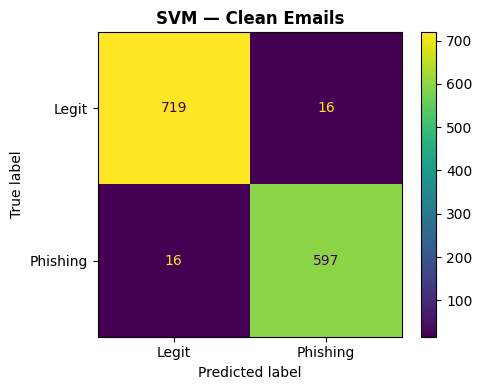

In [ ]:
# SVM: Evaluate on clean emails
svm_pred_clean = svm.predict(X_test_tfidf)
svm_prob_clean = svm.predict_proba(X_test_tfidf)[:, 1]
evaluate('SVM', y_test, svm_pred_clean, svm_prob_clean, split='clean')
plot_cm(y_test, svm_pred_clean, 'SVM — Clean Emails')


=== SVM  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99       735
    Phishing       0.98      0.98      0.98       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9984
EER : 0.0150  (lower is better)


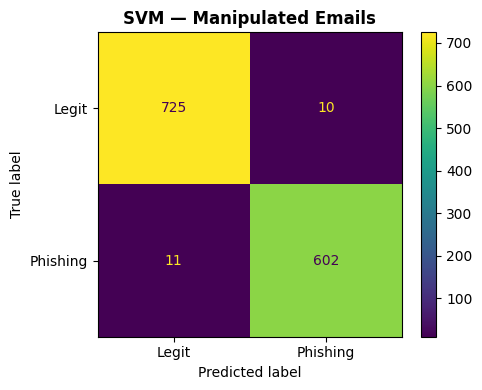

In [ ]:
# SVM: Evaluate on manipulated emails
svm_pred_manip = svm.predict(X_test_manip_tfidf)
svm_prob_manip = svm.predict_proba(X_test_manip_tfidf)[:, 1]
evaluate('SVM', y_test, svm_pred_manip, svm_prob_manip, split='manip')
plot_cm(y_test, svm_pred_manip, 'SVM — Manipulated Emails')

In [ ]:
# CNN: Tokenize text into integer sequences

MAX_WORDS = 10000  # vocabulary size
MAX_LEN   = 200    # max tokens per email (truncated/padded)

keras_tok = KerasTokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train_robust_text)

X_train_cnn       = pad_sequences(keras_tok.texts_to_sequences(X_train_robust_text), maxlen=MAX_LEN)
X_test_cnn_clean  = pad_sequences(keras_tok.texts_to_sequences(X_test_text),         maxlen=MAX_LEN)
X_test_cnn_manip  = pad_sequences(keras_tok.texts_to_sequences(X_test_manip_text),   maxlen=MAX_LEN)

print(f'Train CNN shape : {X_train_cnn.shape}')
print(f'Test clean shape: {X_test_cnn_clean.shape}')
print(f'Test manip shape: {X_test_cnn_manip.shape}')

Train CNN shape : (10776, 200)
Test clean shape: (1348, 200)
Test manip shape: (1348, 200)


In [ ]:
# CNN: Build model
# Architecture: Embedding → Conv1D → GlobalMaxPool → Dense → Output
def build_cnn(vocab_size=MAX_WORDS, embed_dim=128, max_len=MAX_LEN):
    model = keras.Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CNN: Train
# EarlyStopping monitors val_loss with patience=5

early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print('Training CNN...')
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_robust,
    epochs=20,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_cnn],
    verbose=1
)
print(f'Training stopped at epoch {len(cnn_history.history["loss"])}')

Training CNN...
Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - accuracy: 0.8778 - loss: 0.2695 - val_accuracy: 0.9635 - val_loss: 0.1034
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 189ms/step - accuracy: 0.9861 - loss: 0.0448 - val_accuracy: 0.9722 - val_loss: 0.0833
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step - accuracy: 0.9974 - loss: 0.0087 - val_accuracy: 0.9722 - val_loss: 0.0858
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 42s 181ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9734 - val_loss: 0.1026
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9697 - val_loss: 0.1385
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 186ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9740 - val_loss: 0.1058
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - accuracy: 0.9999 - loss: 7.9903e-04 - val_accuracy: 0.9765 - val_loss: 0.1172
Training stopped at epoch 7


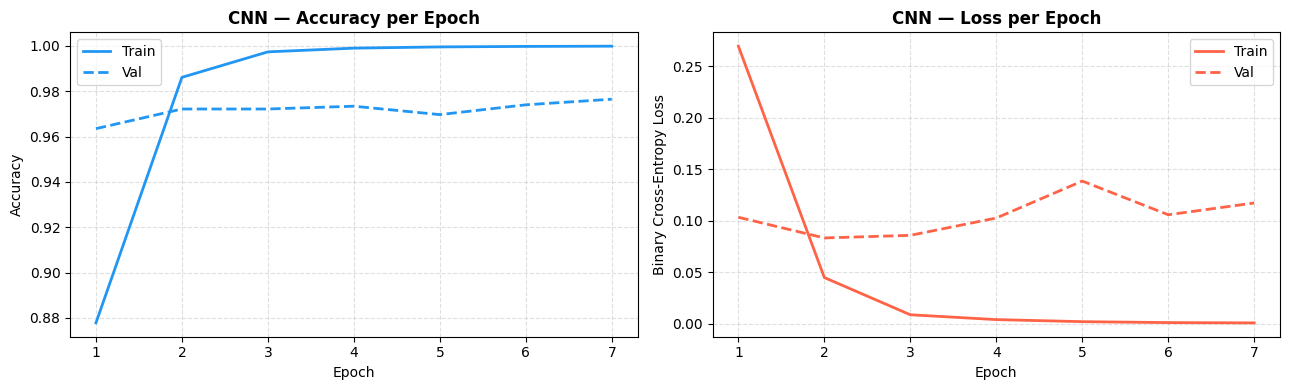

In [ ]:
#CNN: Plot training history
plot_training_history(cnn_history, 'CNN')

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

=== CNN  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98       735
    Phishing       0.97      0.98      0.98       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9976
EER : 0.0218  (lower is better)


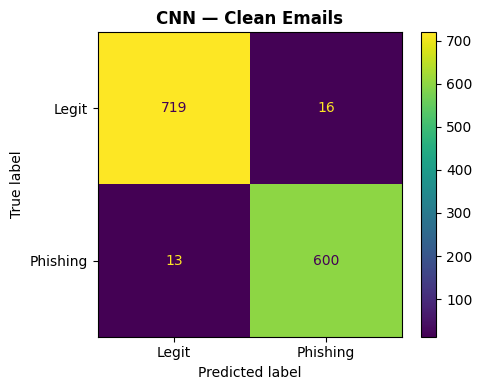

In [ ]:
# CNN: Evaluate on clean emails
cnn_prob_clean = cnn_model.predict(X_test_cnn_clean).flatten()
cnn_pred_clean = (cnn_prob_clean >= 0.5).astype(int)
evaluate('CNN', y_test, cnn_pred_clean, cnn_prob_clean, split='clean')
plot_cm(y_test, cnn_pred_clean, 'CNN — Clean Emails')

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

=== CNN  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98       735
    Phishing       0.96      0.98      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.98      0.97      1348
weighted avg       0.98      0.97      0.97      1348

AUC : 0.9967
EER : 0.0245  (lower is better)


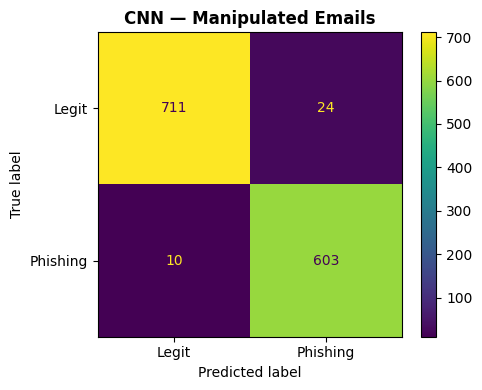

In [ ]:
# CNN: Evaluate on manipulated emails
cnn_prob_manip = cnn_model.predict(X_test_cnn_manip).flatten()
cnn_pred_manip = (cnn_prob_manip >= 0.5).astype(int)
evaluate('CNN', y_test, cnn_pred_manip, cnn_prob_manip, split='manip')
plot_cm(y_test, cnn_pred_manip, 'CNN — Manipulated Emails')

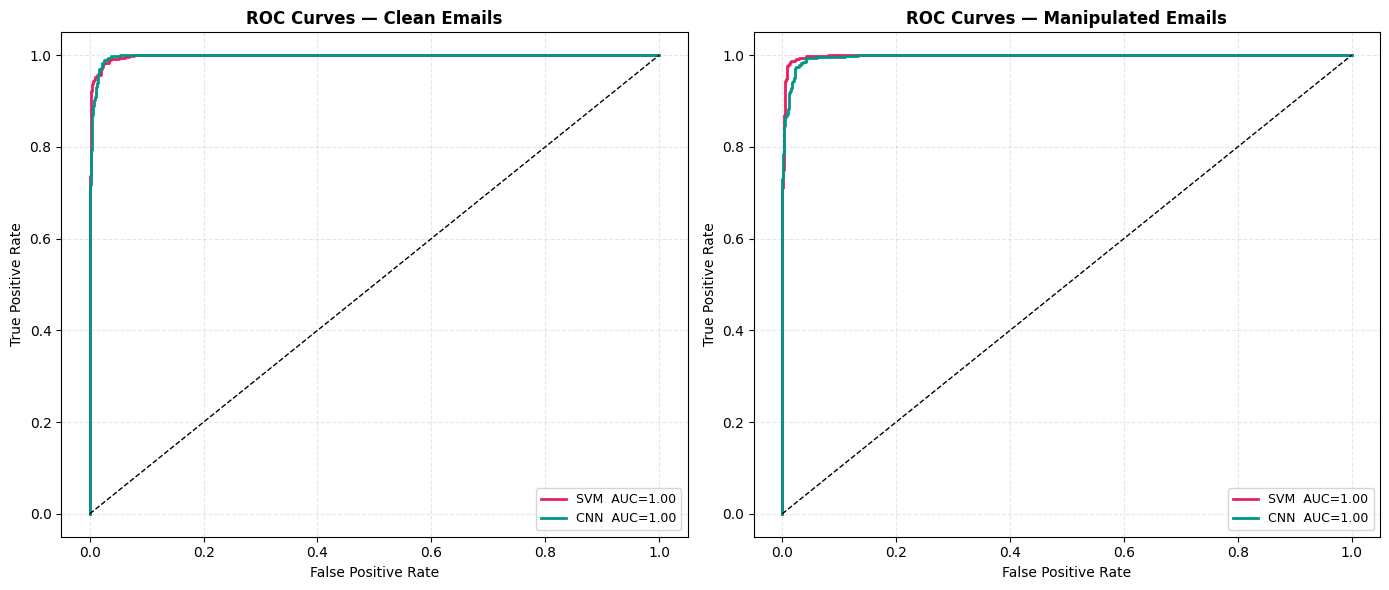

In [ ]:
# Combined ROC curves for SVM and CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'SVM': '#E91E63', 'CNN': '#009688'}

for ax, split, title in zip(axes, ['clean', 'manip'], ['Clean Emails', 'Manipulated Emails']):
    for name, data in roc_data.items():
        if split in data:
            fpr, tpr, roc_auc = data[split]
            ax.plot(fpr, tpr, label=f'{name}  AUC={roc_auc:.2f}', color=colors[name], linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('roc_svm_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary tables for SVM and CNN

metric_cols = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC', 'EER']

clean_df = pd.DataFrame(results_clean).T[metric_cols]
manip_df = pd.DataFrame(results_manip).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS — SVM & CNN')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  MANIPULATED EMAILS — SVM & CNN')
print('='*65)
print(manip_df.round(4).to_string())


  CLEAN EMAILS — SVM & CNN
     Accuracy      F1  Precision  Recall     AUC     EER
SVM    0.9763  0.9739     0.9739  0.9739  0.9979  0.0231
CNN    0.9785  0.9764     0.9740  0.9788  0.9976  0.0218

  MANIPULATED EMAILS — SVM & CNN
     Accuracy      F1  Precision  Recall     AUC     EER
SVM    0.9844  0.9829     0.9837  0.9821  0.9984  0.0150
CNN    0.9748  0.9726     0.9617  0.9837  0.9967  0.0245


In [ ]:
# Adversarial email generator
# Three attack types: homoglyphs, invisible chars, ham injection


import unicodedata
import random

# Homoglyph map — visually identical Unicode replacements
HOMOGLYPH_MAP = {
    'a': 'а',  # Cyrillic а
    'e': 'е',  # Cyrillic е
    'o': 'о',  # Cyrillic о
    'p': 'р',  # Cyrillic р
    'c': 'с',  # Cyrillic с
    'x': 'х',  # Cyrillic х
    'i': 'і',  # Ukrainian і
    's': 'ѕ',  # Cyrillic ѕ
}

# Ham words to inject — legit-sounding phrases to confuse models
HAM_PHRASES = [
    'privacy policy', 'unsubscribe', 'disclaimer',
    'terms of service', 'you are receiving this because',
    'click here to unsubscribe', 'this is not spam',
    'safe and secure', 'your information is protected',
    'compliance', 'legal notice'
]

def apply_homoglyphs(text, severity=0.3):
    """Replace a fraction of eligible characters with homoglyphs"""
    result = []
    for char in text:
        if char.lower() in HOMOGLYPH_MAP and random.random() < severity:
            # preserve case roughly
            result.append(HOMOGLYPH_MAP[char.lower()])
        else:
            result.append(char)
    return ''.join(result)

def apply_invisible_chars(text, severity=0.2):
    """Insert zero-width spaces between characters randomly"""
    ZERO_WIDTH = '\u200b'  # zero-width space, invisible to humans
    result = []
    for char in text:
        result.append(char)
        if random.random() < severity:
            result.append(ZERO_WIDTH)
    return ''.join(result)

def apply_ham_injection(text, n_phrases=2):
    """Inject ham-like phrases at random positions in the text"""
    words = text.split()
    for _ in range(n_phrases):
        phrase = random.choice(HAM_PHRASES)
        position = random.randint(0, len(words))
        words.insert(position, phrase)
    return ' '.join(words)

def generate_adversarial_email(text, severity=0.3):
    """Apply all three attacks in sequence"""
    text = apply_homoglyphs(text, severity=severity)
    text = apply_invisible_chars(text, severity=severity)
    text = apply_ham_injection(text, n_phrases=2)
    return text

# Test it
sample = X_test_text[0]
adversarial_sample = generate_adversarial_email(sample)
print('ORIGINAL:')
print(sample[:200])
print('\nADVERSARIAL:')
print(adversarial_sample[:200])

ORIGINAL:
subject new turn ons tom production commenced to flow as stated below please create a base load ticket in sitara based upon the following information counterparty meter no volumes price period union g

ADVERSARIAL:
ѕ​ubject ​n​еw​ t​urn ​оns tom​ р​r​o​d​uc​tiоn сomm​ence​d​ to f​low as s​tа​ted ​belo​w​ ​p​l​eaѕe с​r​eа​tе a​ b​ase​ lоad​ t​icke​t in s​i​tara ba​sеd​ uр​o​n the​ fоllow​i​n​g​ informa​tion​ ​cou


In [ ]:
#Generate adversarial test set


random.seed(42)  # reproducibility
X_test_adversarial = np.array([generate_adversarial_email(t) for t in X_test_text])

# TF-IDF transform for SVM (same vectorizer from Cell 8)
X_test_adversarial_tfidf = tfidf.transform(X_test_adversarial)

print(f'Adversarial test set size: {len(X_test_adversarial)}')
print('Sample adversarial email:')
print(X_test_adversarial[0][:300])

Adversarial test set size: 1348
Sample adversarial email:
s​ubj​есt n​еw​ turn​ on​s ​tom​ рr​odu​сtі​on соm​m​enc​е​d​ t​o f​l​ow​ ​аs sta​t​еd belo​w рl​е​ase​ ​creat​e a ba​se​ l​oad​ tісkеt ​і​n ѕіt​аra ​ba​s​еd ​u​рo​n the f​ol​lоw​ing​ іnf​o​r​matio​n coun​te​rра​r​t​y ​met​еr​ nо your information is protected ​vo​l​ume​s pr​i​ce реr​i​оd uni​o​n​ ga



=== SVM  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       0.96      0.03      0.06       735
    Phishing       0.46      1.00      0.63       613

    accuracy                           0.47      1348
   macro avg       0.71      0.52      0.35      1348
weighted avg       0.73      0.47      0.32      1348

AUC : 0.8624
EER : 0.2136  (lower is better)


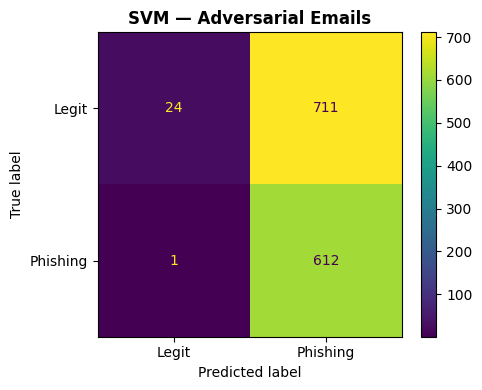

In [ ]:
#  SVM: Evaluate on adversarial test set
svm_pred_adv = svm.predict(X_test_adversarial_tfidf)
svm_prob_adv = svm.predict_proba(X_test_adversarial_tfidf)[:, 1]
evaluate('SVM', y_test, svm_pred_adv, svm_prob_adv, split='adversarial')
plot_cm(y_test, svm_pred_adv, 'SVM — Adversarial Emails')

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

=== CNN  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       1.00      0.13      0.22       735
    Phishing       0.49      1.00      0.66       613

    accuracy                           0.52      1348
   macro avg       0.74      0.56      0.44      1348
weighted avg       0.77      0.52      0.42      1348

AUC : 0.8032
EER : 0.2830  (lower is better)


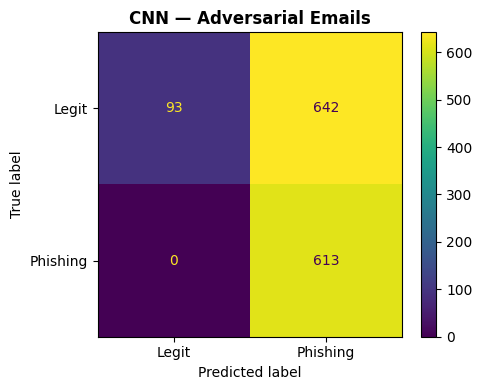

In [ ]:


# CNN: Evaluate on adversarial test set

X_test_cnn_adv = pad_sequences(
    keras_tok.texts_to_sequences(X_test_adversarial),
    maxlen=MAX_LEN
)

cnn_prob_adv = cnn_model.predict(X_test_cnn_adv).flatten()
cnn_pred_adv = (cnn_prob_adv >= 0.5).astype(int)
evaluate('CNN', y_test, cnn_pred_adv, cnn_prob_adv, split='adversarial')
plot_cm(y_test, cnn_pred_adv, 'CNN — Adversarial Emails')

In [ ]:
# Normal trained SVM (clean data only) for comparison
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

tfidf_normal = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf_normal  = tfidf_normal.fit_transform(X_train_text)
X_test_tfidf_normal   = tfidf_normal.transform(X_test_text)
X_test_manip_normal   = tfidf_normal.transform(X_test_manip_text)
X_test_adv_normal     = tfidf_normal.transform(X_test_adversarial)

svm_normal_base = LinearSVC(max_iter=2000, random_state=42, C=1.0)
svm_normal      = CalibratedClassifierCV(svm_normal_base, cv=5)
svm_normal.fit(X_train_tfidf_normal, y_train)
print('Normal SVM trained')

# Evaluate all 3 conditions
svm_n_pred_clean = svm_normal.predict(X_test_tfidf_normal)
svm_n_prob_clean = svm_normal.predict_proba(X_test_tfidf_normal)[:, 1]
evaluate('SVM (Normal)', y_test, svm_n_pred_clean, svm_n_prob_clean, split='clean')

svm_n_pred_manip = svm_normal.predict(X_test_manip_normal)
svm_n_prob_manip = svm_normal.predict_proba(X_test_manip_normal)[:, 1]
evaluate('SVM (Normal)', y_test, svm_n_pred_manip, svm_n_prob_manip, split='manip')

svm_n_pred_adv = svm_normal.predict(X_test_adv_normal)
svm_n_prob_adv = svm_normal.predict_proba(X_test_adv_normal)[:, 1]
evaluate('SVM (Normal)', y_test, svm_n_pred_adv, svm_n_prob_adv, split='adversarial')

print('Normal SVM evaluation done')

Normal SVM trained

=== SVM (Normal)  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98       735
    Phishing       0.98      0.98      0.98       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9987
EER : 0.0177  (lower is better)

=== SVM (Normal)  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.71      0.02      0.04       735
    Phishing       0.46      0.99      0.63       613

    accuracy                           0.46      1348
   macro avg       0.58      0.51      0.34      1348
weighted avg       0.59      0.46      0.31      1348

AUC : 0.7481
EER : 0.3306  (lower is better)

=== SVM (Normal)  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       1.00      0.01      0.03       735
    Phishing       0.46      

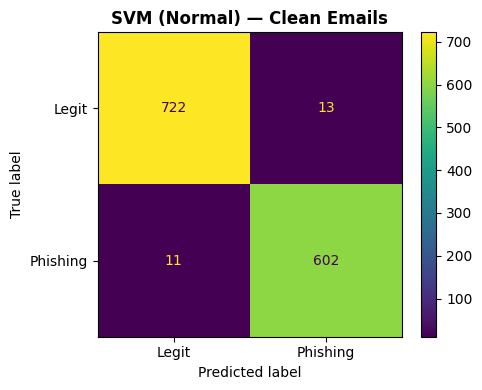

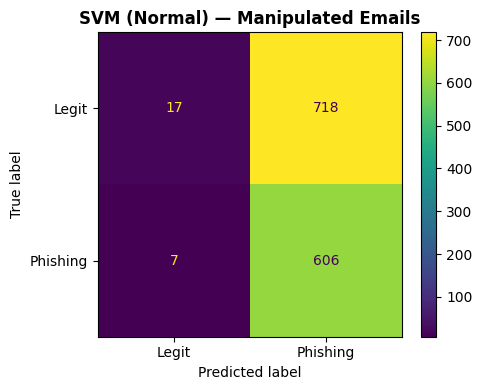

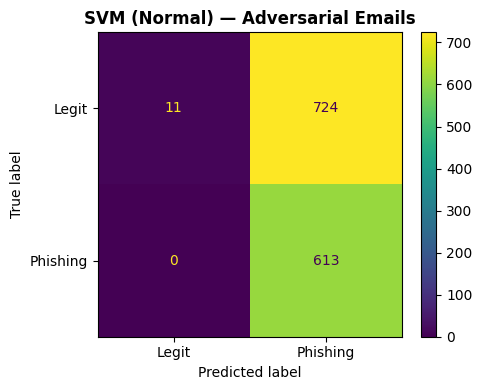

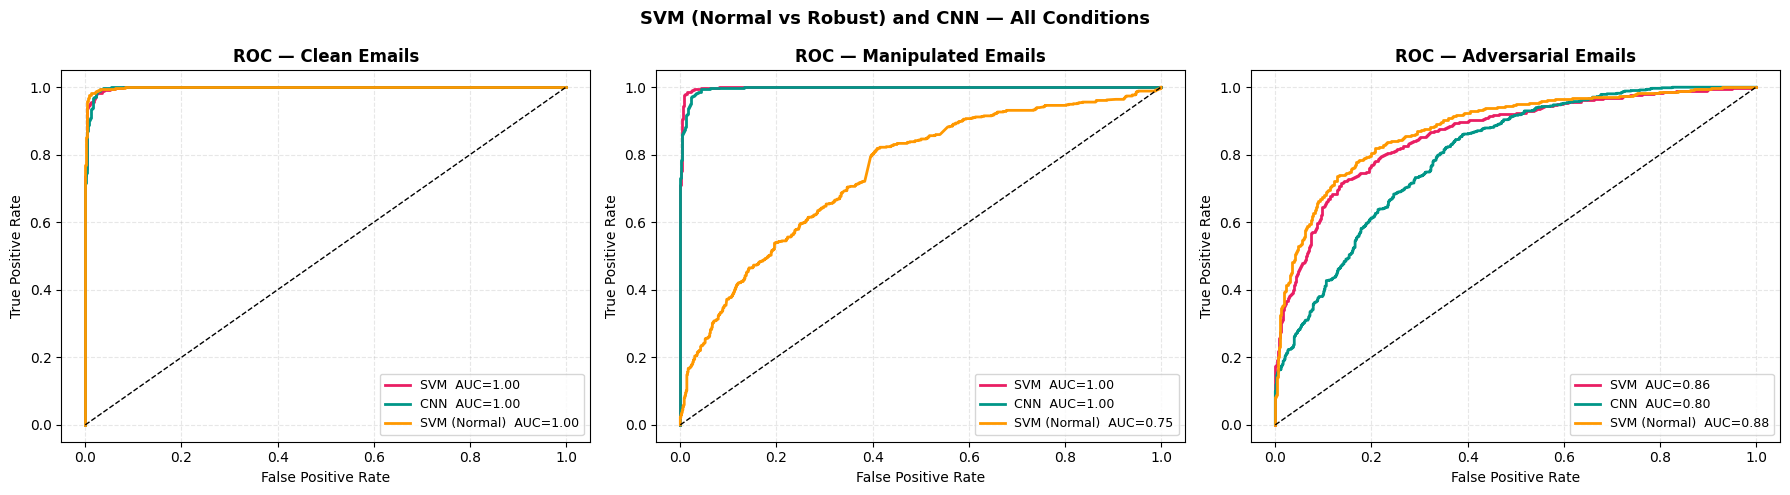

In [ ]:
# Normal SVM — Confusion matrices
plot_cm(y_test, svm_n_pred_clean, 'SVM (Normal) — Clean Emails')
plot_cm(y_test, svm_n_pred_manip, 'SVM (Normal) — Manipulated Emails')
plot_cm(y_test, svm_n_pred_adv,   'SVM (Normal) — Adversarial Emails')

# ROC curves — Robust SVM vs Normal SVM across all conditions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = ['clean', 'manip', 'adversarial']
titles = ['Clean Emails', 'Manipulated Emails', 'Adversarial Emails']

colors = {
    'SVM':          '#E91E63',  # robust SVM — solid pink
    'SVM (Normal)': '#FF9800',  # normal SVM — orange
    'CNN':          '#009688',  # CNN — teal
}

for ax, split, title in zip(axes, splits, titles):
    for name, data in roc_data.items():
        if split in data and name in colors:
            fpr, tpr, roc_auc = data[split]
            ax.plot(fpr, tpr,
                    label=f'{name}  AUC={roc_auc:.2f}',
                    color=colors[name],
                    linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {title}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('SVM (Normal vs Robust) and CNN — All Conditions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('roc_normal_vs_robust.png', dpi=150, bbox_inches='tight')
plt.show()

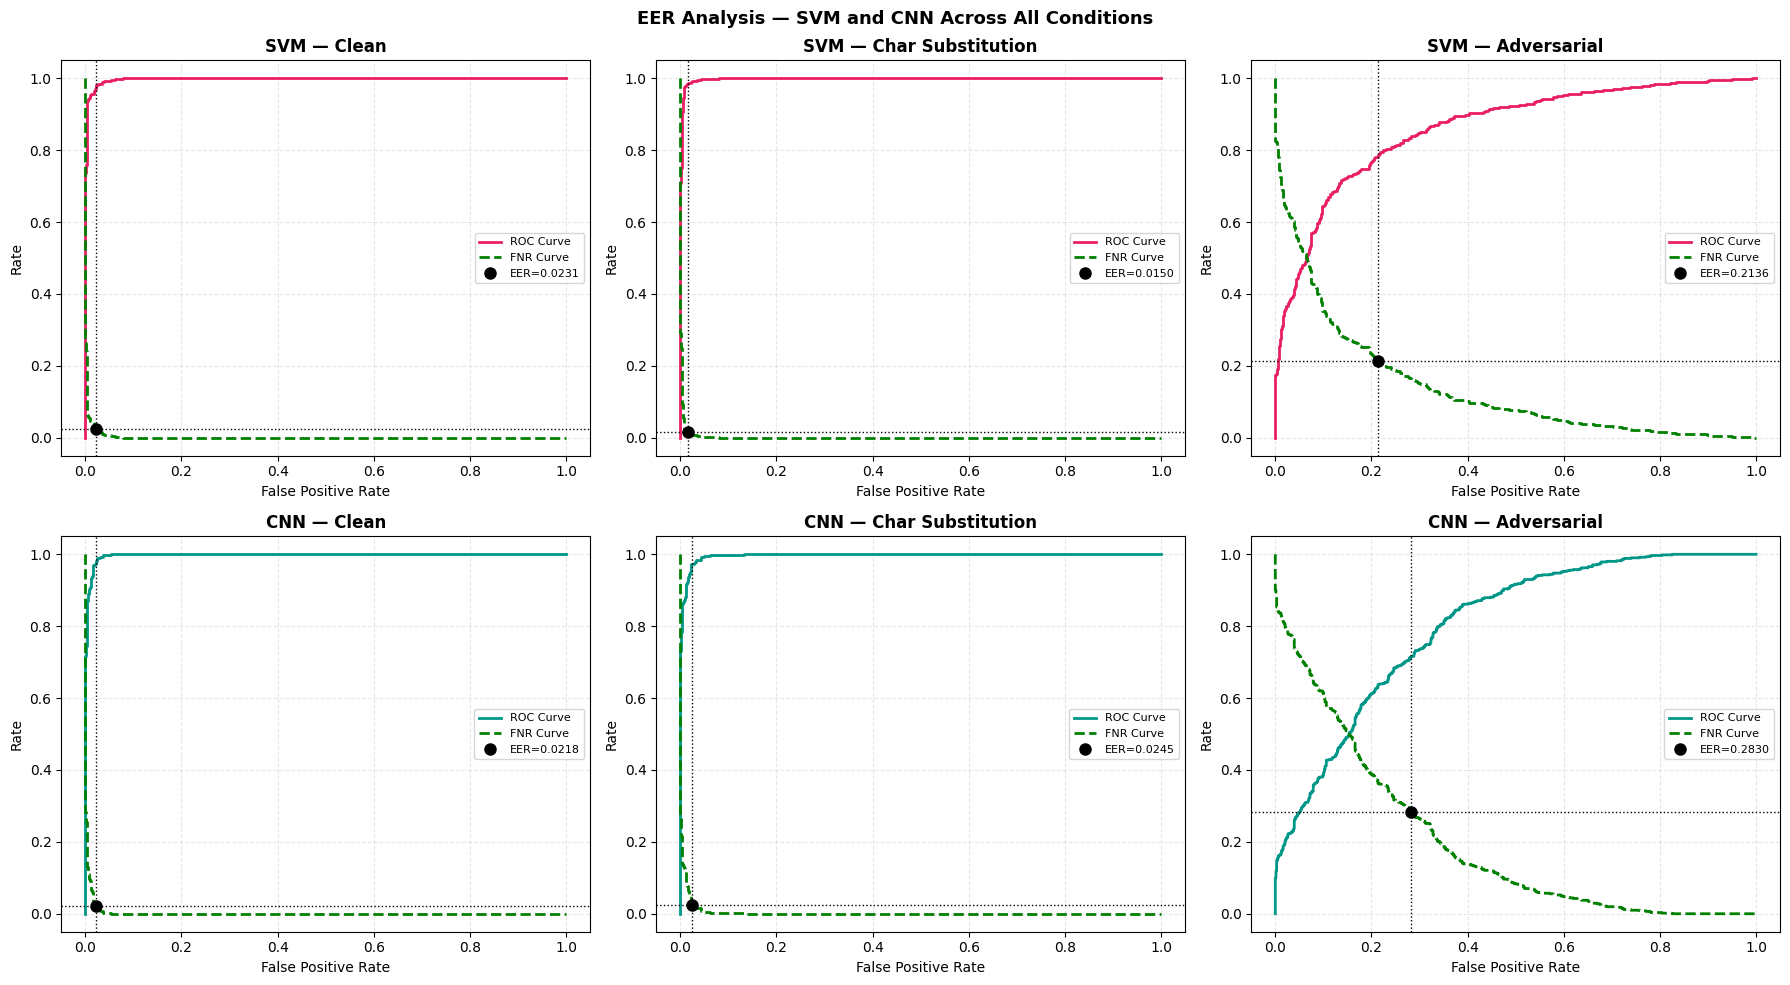

In [ ]:
#  EER plot for SVM and CNN

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_to_plot = ['SVM', 'CNN']
conditions = ['clean', 'manip', 'adversarial']
titles = ['Clean', 'Char Substitution', 'Adversarial']
colors = {'SVM': '#E91E63', 'CNN': '#009688'}

for row, model in enumerate(models_to_plot):
    for col, (split, title) in enumerate(zip(conditions, titles)):
        ax = axes[row][col]
        if model in roc_data and split in roc_data[model]:
            fpr, tpr, roc_auc = roc_data[model][split]
            fnr = 1 - tpr
            eer = float(fpr[np.nanargmin(np.abs(fnr - fpr))])
            ax.plot(fpr, tpr,  color=colors[model], linewidth=2, label='ROC Curve')
            ax.plot(fpr, fnr,  color='green',        linewidth=2, label='FNR Curve', linestyle='--')
            ax.plot(eer, eer,  'ko', markersize=8,   label=f'EER={eer:.4f}')
            ax.axvline(x=eer, color='black', linestyle=':', linewidth=1)
            ax.axhline(y=eer, color='black', linestyle=':', linewidth=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('Rate')
        ax.set_title(f'{model} — {title}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('EER Analysis — SVM and CNN Across All Conditions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eer_svm_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Full comparison table: SVM and CNN across all conditions
import pandas as pd

metric_cols = ['Accuracy', 'F1', 'AUC', 'EER']

clean_df = pd.DataFrame(results_clean).T[metric_cols]
manip_df = pd.DataFrame(results_manip).T[metric_cols]
adv_df   = pd.DataFrame(results_adv).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  CHAR SUBSTITUTION')
print('='*65)
print(manip_df.round(4).to_string())

print('\n' + '='*65)
print('  ADVERSARIAL ATTACK')
print('='*65)
print(adv_df.round(4).to_string())


  CLEAN EMAILS
              Accuracy      F1     AUC     EER
SVM             0.9763  0.9739  0.9979  0.0231
CNN             0.9785  0.9764  0.9976  0.0218
SVM (Normal)    0.9822  0.9805  0.9987  0.0177

  CHAR SUBSTITUTION
              Accuracy      F1     AUC     EER
SVM             0.9844  0.9829  0.9984  0.0150
CNN             0.9748  0.9726  0.9967  0.0245
SVM (Normal)    0.4622  0.6257  0.7481  0.3306

  ADVERSARIAL ATTACK
              Accuracy      F1     AUC     EER
SVM             0.4718  0.6322  0.8624  0.2136
CNN             0.5237  0.6563  0.8032  0.2830
SVM (Normal)    0.4629  0.6287  0.8811  0.1986


In [ ]:
# ============================================================
# CELL — Save all results + plots to Drive
# ============================================================
import json
import shutil
import os

# Save plots
drive_plots = '/content/drive/MyDrive/CS271/svm_cnn_plots/'
os.makedirs(drive_plots, exist_ok=True)

for fname in ['roc_svm_cnn.png', 'roc_normal_vs_robust.png']:
    if os.path.exists(fname):
        shutil.copy(fname, drive_plots + fname)
        print(f'Saved plot: {fname}')
    else:
        print(f'Plot not found: {fname}')

# Build results dict
svm_cnn_results = {
    'clean':            {},
    'manip':            {},
    'adversarial':      {},
    'training_history': {},
    'roc_curves':       {}
}

# Clean, manip, adversarial from evaluate() dicts
for model, metrics in results_clean.items():
    svm_cnn_results['clean'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

for model, metrics in results_manip.items():
    svm_cnn_results['manip'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

for model, metrics in results_adv.items():
    svm_cnn_results['adversarial'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

# CNN training history
svm_cnn_results['training_history']['CNN'] = {
    'accuracy':     [round(float(x), 4) for x in cnn_history.history['accuracy']],
    'val_accuracy': [round(float(x), 4) for x in cnn_history.history['val_accuracy']],
    'loss':         [round(float(x), 4) for x in cnn_history.history['loss']],
    'val_loss':     [round(float(x), 4) for x in cnn_history.history['val_loss']]
}

# ROC curves
for model_name, splits in roc_data.items():
    svm_cnn_results['roc_curves'][model_name] = {}
    for split_name, (fpr, tpr, roc_auc) in splits.items():
        svm_cnn_results['roc_curves'][model_name][split_name] = {
            'fpr': [round(float(x), 4) for x in fpr],
            'tpr': [round(float(x), 4) for x in tpr],
            'auc': round(float(roc_auc), 4)
        }

# Save JSON
save_path = '/content/drive/MyDrive/CS271/svm_cnn_results.json'
with open(save_path, 'w') as f:
    json.dump(svm_cnn_results, f, indent=2)

print('\nSaved to:', save_path)
print('Clean models:      ', list(svm_cnn_results['clean'].keys()))
print('Manip models:      ', list(svm_cnn_results['manip'].keys()))
print('Adversarial models:', list(svm_cnn_results['adversarial'].keys()))

# Verification
print('\nVERIFICATION:')
for model in ['SVM', 'CNN', 'SVM (Normal)']:
    c = svm_cnn_results['clean'].get(model, {}).get('Accuracy', 'missing')
    m = svm_cnn_results['manip'].get(model, {}).get('Accuracy', 'missing')
    a = svm_cnn_results['adversarial'].get(model, {}).get('Accuracy', 'missing')
    print(f'{model}: clean={c}, manip={m}, adv={a}')

Saved plot: roc_svm_cnn.png
Saved plot: roc_normal_vs_robust.png

Saved to: /content/drive/MyDrive/CS271/svm_cnn_results.json
Clean models:       ['SVM', 'CNN', 'SVM (Normal)']
Manip models:       ['SVM', 'CNN', 'SVM (Normal)']
Adversarial models: ['SVM', 'CNN', 'SVM (Normal)']

VERIFICATION:
SVM: clean=0.9763, manip=0.9844, adv=0.4718
CNN: clean=0.9785, manip=0.9748, adv=0.5237
SVM (Normal): clean=0.9822, manip=0.4622, adv=0.4629
